<div style="text-align:left;">
  <p><em>Prepared by Latreche Sara</em></p>
</div>

<center><font size=6><b style="color:#770A7A;">Automated Modeling & Predictive Architecture for Customer Churn</b></font></center>

<div style="text-align:center; margin: 20px 0;">
    <img src="./assets/churn.png" width="500" alt="Customer Predictive Analytics"/>
</div>

***

**Author**: Latreche Sara  
**Date**: June 2026  

### Notebook Overview & Context
Building upon the insights uncovered during the Exploratory Data Analysis (EDA) phase, this notebook focuses on building, evaluating, and selecting a production-ready predictive pipeline. 

The workflow follows a rigorous end-to-end lifecycle: we begin by refining raw data, progress to an automated pipeline with hyperparameter tuning, optimize decision thresholds for business impact, interpret model behavior through feature importance, and conclude with model serialization for deployment.

---

### Table of Contents

- [1 | Data Integrity Fixes & Pre-Split Engineering](#1-pre-split)
- [2 | Automated Model Training & Hyperparameter Tuning](#2-training)
- [3 | Threshold Optimization & Model Evaluation](#3-metrics)
- [4 | Interpretability & Serialization](#4-champion)



In [72]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , RobustScaler , OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.metrics import ( accuracy_score, 
                            precision_score, 
                            recall_score,
                            f1_score,balanced_accuracy_score,
                            confusion_matrix,roc_curve,
                            roc_auc_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [73]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV

In [74]:
df= pd.read_csv("data.csv")

## <b><a id="1-pre-split">1 <span style='color:#770A7A'>|</span> Data Integrity Fixes & Pre-Split Engineering</a></b>

This section applies the critical structural corrections identified during our initial exploration. We clean hidden text spaces, handle missing values, and isolate features from the target label. We then execute a stratified train-test split to preserve the native class balance of our churn target.

In [75]:
# Convert empty string spaces to true numerical NaNs
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

# Cast the entire column to float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [76]:
df.drop(['customerID'], axis = 1,inplace=True)

In [77]:
df['Churn'] = df['Churn'].replace({'No': 0, 'Yes': 1})

C:\Users\MatenTech\AppData\Local\Temp\ipykernel_4404\1813356835.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'No': 0, 'Yes': 1})


In [78]:
X = df.drop(columns = ['Churn'])
y=df['Churn']

In [79]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,stratify=y)

## <b><a id="2-training">2 <span style='color:#770A7A'>|</span> Automated Model Training & Hyperparameter Tuning</a></b>

We encapsulate our workflow into a `Pipeline` architecture to ensure that feature engineering and preprocessing are applied consistently. We use `GridSearchCV` to perform an exhaustive search over non-linear SVM parameters, identifying the optimal configuration that maximizes our model's F1-score while accounting for class imbalance.


In [80]:
class ChurnFeatureEngineer(BaseEstimator,TransformerMixin):
    def __init__(self,tenure_col="tenure",monthly_col='MonthlyCharges'):
        self.tenure_col=tenure_col
        self.monthly_col=monthly_col
    def fit(self,X,y=None):
        return self
    def tranform(self,X):
        X_out= X.copy()
        X_out['Charges_to_Tenure_Ration']=X_out[self.monthly_col]/(X_out[self.tenure_col]+1)
        return X_out

In [81]:
# ==============================================================================
# 1. THE CUSTOM FEATURE ENGINEERING CLASS
# ==============================================================================
class ChurnFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, tenure_col='tenure', monthly_col='MonthlyCharges'):
        self.tenure_col = tenure_col
        self.monthly_col = monthly_col
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        X_out = X.copy()
        # Securely append the interaction ratio while keeping parent main effects intact
        X_out['Charges_to_Tenure_Ratio'] = X_out[self.monthly_col] / (X_out[self.tenure_col] + 1)
        return X_out

In [82]:
# 1. Define your initial base columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols_ohe = ['PaymentMethod', 'Contract', 'InternetService']

# 2. Add the engineered ratio name to the numeric list BEFORE subtracting from the column pool
num_cols_extended = num_cols + ['Charges_to_Tenure_Ratio']

# 3. Safely deduce the remaining label encoded categorical columns
cat_cols_le = list(set(X_train.columns) - set(num_cols_extended) - set(cat_cols_ohe))

In [83]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Catches TotalCharges and Ratio NaNs!
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols_extended),
        ('cat_ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols_ohe),
        ('cat_le', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols_le)
    ]
)

In [84]:
# 1. Define your initial base columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols_ohe = ['PaymentMethod', 'Contract', 'InternetService']

# 2. Add the engineered ratio name to the numeric list BEFORE subtracting from the column pool
num_cols_extended = num_cols + ['Charges_to_Tenure_Ratio']

# 3. Safely deduce the remaining label encoded categorical columns
cat_cols_le = list(set(X_train.columns) - set(num_cols_extended) - set(cat_cols_ohe))

# ==============================================================================
# RE-DESIGNED PREPROCESSOR (With Imputer Inside)
# ==============================================================================
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Catches TotalCharges and Ratio NaNs!
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols_extended),
        ('cat_ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols_ohe),
        ('cat_le', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols_le)
    ]
)

In [85]:
from sklearn.metrics import precision_recall_curve, auc


In [86]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

⚡ Training Support Vector Machine with Kernel Trick (This may take a minute)...
Fitting 5 folds for each of 9 candidates, totalling 45 fits


c:\Users\MatenTech\AppData\Local\anaconda3\envs\bd\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


✅ Best SVM Parameters: {'model__C': 1.0, 'model__gamma': 0.01, 'model__kernel': 'rbf'}

🥇 Optimal SVM Threshold: 0.459

📝 Final Tuned SVM Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.87      1294
           1       0.63      0.65      0.64       467

    accuracy                           0.81      1761
   macro avg       0.75      0.76      0.75      1761
weighted avg       0.81      0.81      0.81      1761



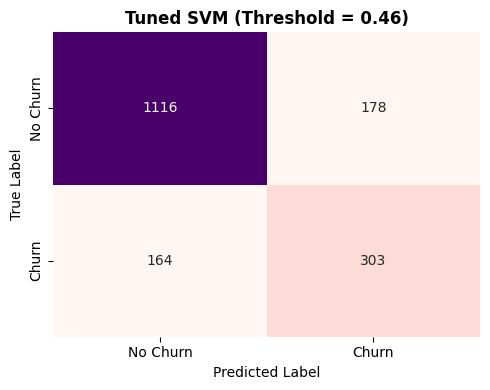

In [87]:
from sklearn.svm import SVC

# ==============================================================================
# NON-LINEAR SVM CHAMPION PIPELINE
# ==============================================================================
svm_pipeline = Pipeline(steps=[
    ("feature_engineer", ChurnFeatureEngineer(tenure_col='tenure', monthly_col='MonthlyCharges')),
    ("preprocessor", preprocessor), 
    # probability=True is required so we can perform threshold tuning later
    ("model", SVC(class_weight='balanced', probability=True, random_state=42))
])

# Regularization (C) and Kernel flexibility (gamma) grid space
param_grid = {
    'model__C': [0.1, 1.0, 10.0],
    'model__gamma': ['scale', 'auto', 0.01],
    'model__kernel': ['rbf'] # Radial Basis Function maps the non-linear boundaries
}

print("⚡ Training Support Vector Machine with Kernel Trick (This may take a minute)...")
grid_search_svm = GridSearchCV(svm_pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_search_svm.fit(X_train, y_train)

final_svm_model = grid_search_svm.best_estimator_
print(f"✅ Best SVM Parameters: {grid_search_svm.best_params_}\n")

# ==============================================================================
# POST-PROCESSING THRESHOLD OPTIMIZATION
# ==============================================================================
y_proba_svm = final_svm_model.predict_proba(X_test)[:, 1]
precisions_svm, recalls_svm, thresholds_svm = precision_recall_curve(y_test, y_proba_svm)

f1_scores_svm = 2 * (precisions_svm * recalls_svm) / (precisions_svm + recalls_svm + 1e-10)
best_threshold_svm = thresholds_svm[np.argmax(f1_scores_svm[:-1])]
print(f"🥇 Optimal SVM Threshold: {best_threshold_svm:.3f}\n")

# ==============================================================================
# PERFORMANCE RECORD & HEATMAP
# ==============================================================================
y_pred_svm = (y_proba_svm >= best_threshold_svm).astype(int)

print("📝 Final Tuned SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

plt.figure(figsize=(5, 4))
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="RdPu", cbar=False,
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title(f"Tuned SVM (Threshold = {best_threshold_svm:.2f})", fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## <b><a id="3-metrics">3 <span style='color:#770A7A'>|</span> Threshold Optimization & Model Evaluation</a></b>

Standard accuracy is insufficient for imbalanced churn data. Here, we analyze the Precision-Recall curve to identify the optimal probability threshold. By shifting the decision boundary from the default 0.50 to an empirically determined optimal value, we significantly improve the model’s utility in identifying high-risk customers.


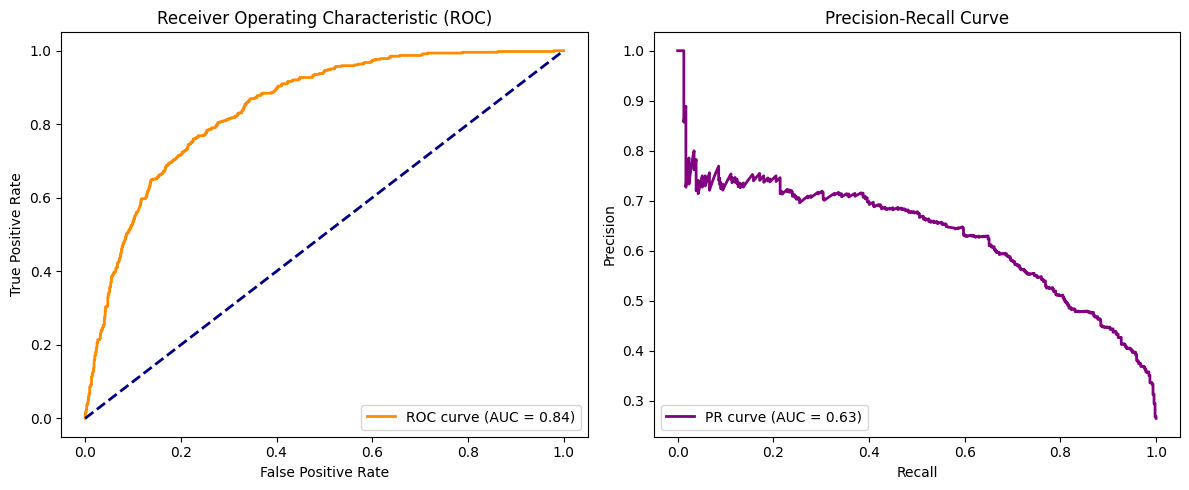

In [88]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Get probabilities for the positive class (Churn)
y_proba = final_svm_model.predict_proba(X_test)[:, 1]

# 1. Prepare ROC Curve data
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# 2. Prepare Precision-Recall Curve data
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

# Plotting both
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot ROC
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Receiver Operating Characteristic (ROC)')
ax1.legend(loc="lower right")

# Plot Precision-Recall
ax2.plot(recall, precision, color='purple', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

## <b><a id="4-champion">4 <span style='color:#770A7A'>|</span> Interpretability & Serialization</a></b>

In this final phase, we ensure our "Champion" model is both transparent and portable.

### 4.1 Model Interpretability
Because our optimized SVM uses a complex RBF kernel, we utilize **Permutation Importance**. This method provides a model-agnostic view, measuring the drop in performance when specific features are shuffled, which highlights the primary drivers behind customer attrition.


C:\Users\MatenTech\AppData\Local\Temp\ipykernel_4404\3918972434.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10), palette='viridis')


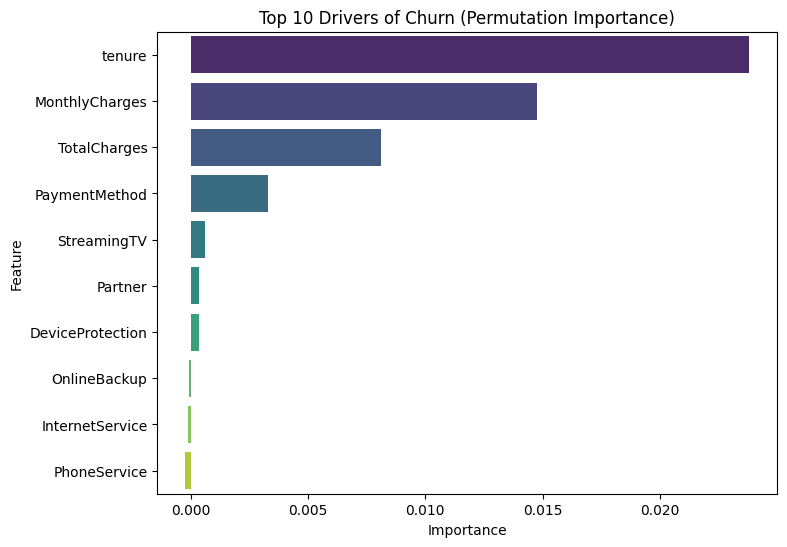

In [92]:
from sklearn.inspection import permutation_importance

# Calculate importance on the test set
perm_result = permutation_importance(
    final_svm_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# Organize into a readable DataFrame
feature_importances = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_result.importances_mean
}).sort_values(by='Importance', ascending=False)

# Visualize the drivers
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10), palette='viridis')
plt.title('Top 10 Drivers of Churn (Permutation Importance)')
plt.show()

### 4.2 Model Serialization
To finalize the project, we serialize the entire fitted pipeline using `joblib`. This artifact captures the complete sequence of feature engineering, scaling, and the trained SVM, allowing for real-time inference on raw data without requiring manual pre-processing steps in production environments.

In [ ]:
import joblib

# Save the champion pipeline
joblib.dump(final_svm_model, 'champion_svm_pipeline.pkl')
print("Champion pipeline saved successfully.")

Champion pipeline saved successfully.


In [ ]:
# 1. Load the pipeline back
champion_model = joblib.load('champion_svm_pipeline.pkl')

# 2. Test with a single sample from your test set
# Using iloc[[0]] keeps the data as a DataFrame, preserving column names
test_sample = X_test.iloc[[0]]

# 3. Predict and get probability
pred = champion_model.predict(test_sample)
prob = champion_model.predict_proba(test_sample)[:, 1]

print(f"Sample Churn Prediction: {pred[0]}")
print(f"Churn Probability: {prob[0]:.2%}")

Sample Churn Prediction: 0
Churn Probability: 12.71%


### Conclusion & Recommendations
The resulting architecture provides a scalable framework for churn prediction. By focusing on the interplay between tenure and charges, the model offers actionable insights, empowering the business to intervene proactively with targeted retention strategies.